In [26]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv
/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv


In [27]:
!pip install imbalanced-learn

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve
)

from imblearn.over_sampling import SMOTE

In [29]:
train_df = pd.read_csv("/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv")

In [30]:
train_df = pd.read_csv("/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv")
test_df  = pd.read_csv("/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (1296675, 23)
Test shape: (555719, 23)


In [31]:
train_df.columns

Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

In [32]:
train_df.isnull().sum()
test_df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [33]:
train_df.fillna("Unknown", inplace=True)
test_df.fillna("Unknown", inplace=True)

In [34]:
X_train = train_df.drop("is_fraud", axis=1)
y_train = train_df["is_fraud"]

X_test = test_df.drop("is_fraud", axis=1)
y_test = test_df["is_fraud"]

In [35]:
num_cols = ["amt"]  # numeric
cat_cols = ["merchant", "category", "first", "last"]  # categorical

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline   # 🔥 THIS WAS MISSING

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

In [37]:
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ])

In [38]:
from imblearn.pipeline import Pipeline

In [44]:
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [45]:
dt = Pipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", DecisionTreeClassifier(max_depth=10, random_state=42))
])

dt.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['amt']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['merchant', 'category',
                                                   'first', 'last'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 DecisionTreeClassifier(max_depth=10, random_state=42))])

In [46]:
def evaluate(model, name):
    print(f"--- {name} ---")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]

    print(classification_report(y_test, y_pred))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [48]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [49]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline   # ✅ ONLY THIS PIPELINE

In [50]:
num_cols = ["amt"]
cat_cols = ["merchant", "category", "first", "last"]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [51]:
rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=15,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

In [52]:
rf.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amt']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['merchant', 'category',
                                                   'first', 'last'])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [57]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression

lr = Pipeline(steps=[
    ("preprocess", preprocess),
    ("smote", SMOTE(random_state=42)),
    ("model", LogisticRegression(max_iter=1000))
])

In [59]:
lr.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amt']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['merchant', 'category',
                                                   'first', 'last'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=1000))])

In [60]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))

              precision    recall  f1-score   support

           0       1.00      0.89      0.94    553574
           1       0.01      0.37      0.02      2145

    accuracy                           0.89    555719
   macro avg       0.50      0.63      0.48    555719
weighted avg       0.99      0.89      0.94    555719

ROC-AUC: 0.6245907073377295


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    553574
           1       0.01      0.37      0.02      2145

    accuracy                           0.89    555719
   macro avg       0.50      0.63      0.48    555719
weighted avg       0.99      0.89      0.94    555719

ROC-AUC Score: 0.6245907073377295


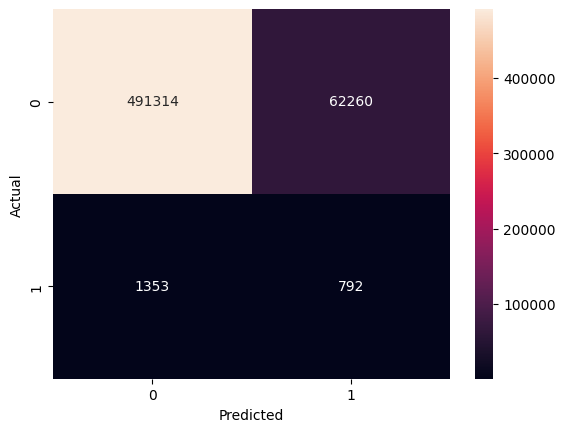

--- Decision Tree ---
              precision    recall  f1-score   support

           0       1.00      0.95      0.98    553574
           1       0.07      0.94      0.13      2145

    accuracy                           0.95    555719
   macro avg       0.54      0.94      0.55    555719
weighted avg       1.00      0.95      0.97    555719

ROC-AUC Score: 0.9761046204497305


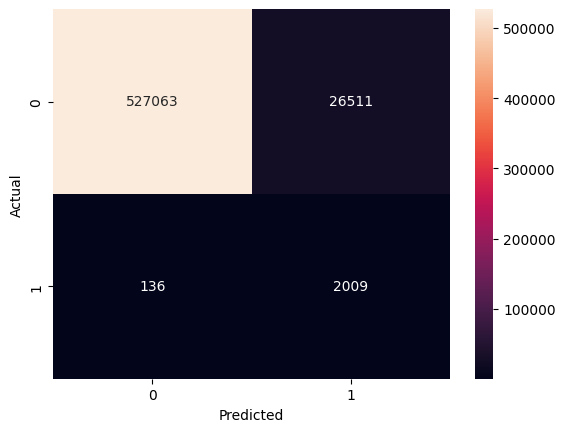

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.12      0.73      0.21      2145

    accuracy                           0.98    555719
   macro avg       0.56      0.86      0.60    555719
weighted avg       1.00      0.98      0.99    555719

ROC-AUC Score: 0.8755124633086749


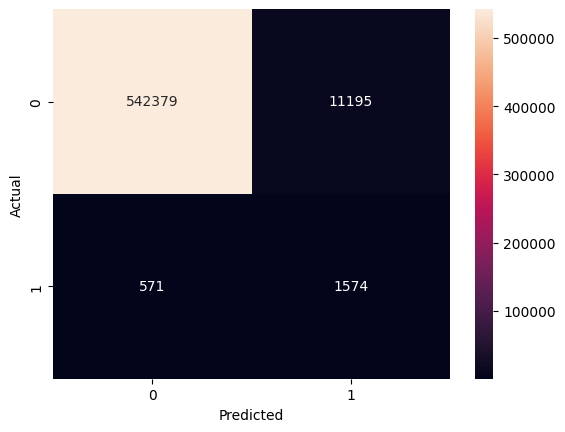

In [61]:
evaluate(lr, "Logistic Regression")
evaluate(dt, "Decision Tree")
evaluate(rf, "Random Forest")

In [62]:
print(type(lr))
print(type(rf))

<class 'imblearn.pipeline.Pipeline'>
<class 'imblearn.pipeline.Pipeline'>


In [63]:
import joblib

joblib.dump(rf, "fraud_detection_model.pkl")
joblib.dump(preprocess, "preprocess.pkl")

['preprocess.pkl']

In [64]:
sample = X_test.sample(5, random_state=42)
predictions = rf.predict(sample)

pd.DataFrame({
    "Prediction": predictions,
    "Actual": y_test.loc[sample.index]
})

,Prediction,Actual
119106,0,0
179292,0,0
540729,0,0
374360,0,0
314574,0,0


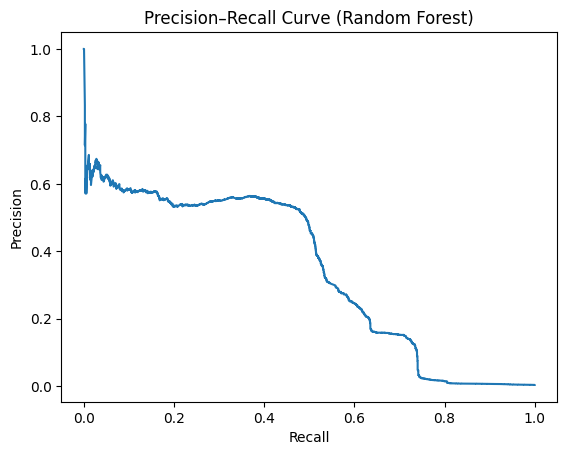

In [65]:
from sklearn.metrics import precision_recall_curve

y_scores = rf.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Random Forest)")
plt.show()

In [68]:
# Get OneHotEncoder directly from ColumnTransformer
ohe = rf.named_steps["preprocess"].named_transformers_["cat"]

cat_feature_names = ohe.get_feature_names_out(cat_cols)

all_features = num_cols + list(cat_feature_names)

In [69]:
rf_model = rf.named_steps["model"]
importances = rf_model.feature_importances_

feature_importance = (
    pd.Series(importances, index=all_features)
    .sort_values(ascending=False)
)

feature_importance.head(15)

amt                        0.373313
category_shopping_net      0.076930
category_home              0.045118
category_grocery_pos       0.043771
category_health_fitness    0.035954
category_food_dining       0.028552
category_misc_net          0.028036
category_kids_pets         0.025943
category_entertainment     0.018809
category_personal_care     0.018293
category_misc_pos          0.015264
category_grocery_net       0.008437
category_travel            0.008193
last_Thomas                0.007226
category_gas_transport     0.005832
dtype: float64

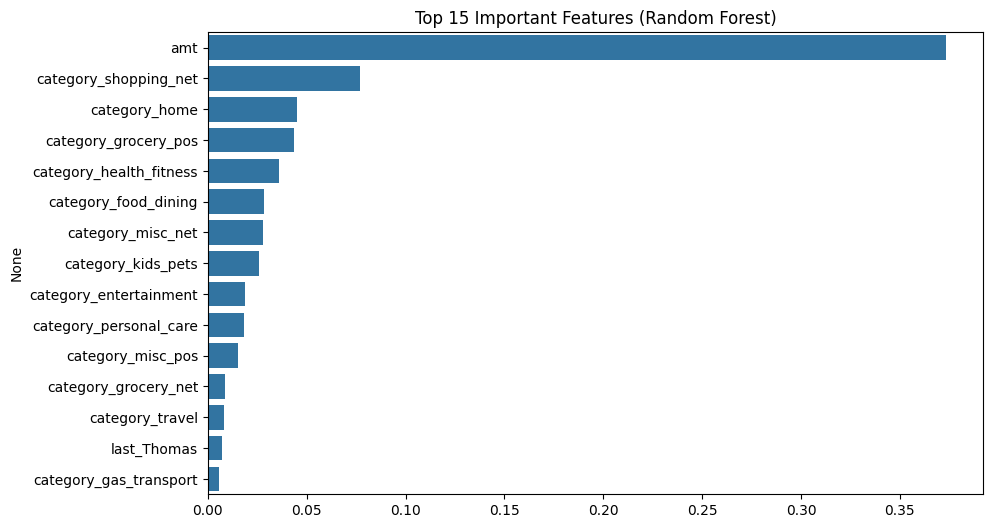

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(
    x=feature_importance.values[:15],
    y=feature_importance.index[:15]
)
plt.title("Top 15 Important Features (Random Forest)")
plt.show()

In [72]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

In [73]:
# Access OneHotEncoder directly from ColumnTransformer
ohe = rf.named_steps["preprocess"].named_transformers_["cat"]

In [75]:
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_features = num_cols + list(cat_feature_names)

In [76]:
rf_model = rf.named_steps["model"]
importances = rf_model.feature_importances_

feature_importance = (
    pd.Series(importances, index=all_features)
    .sort_values(ascending=False)
)

feature_importance.head(15)

amt                        0.373313
category_shopping_net      0.076930
category_home              0.045118
category_grocery_pos       0.043771
category_health_fitness    0.035954
category_food_dining       0.028552
category_misc_net          0.028036
category_kids_pets         0.025943
category_entertainment     0.018809
category_personal_care     0.018293
category_misc_pos          0.015264
category_grocery_net       0.008437
category_travel            0.008193
last_Thomas                0.007226
category_gas_transport     0.005832
dtype: float64

In [78]:
rf_model = rf.named_steps["model"]
rf_model.feature_importances_[:10]

array([3.73312613e-01, 3.37255857e-06, 2.95955046e-05, 1.42343199e-05,
       2.50898401e-05, 2.55773632e-05, 8.57057911e-06, 4.20165314e-04,
       1.17299157e-04, 3.80875851e-04])

In [80]:
# get trained Random Forest
rf_model = rf.named_steps["model"]

# get OneHotEncoder correctly
ohe = rf.named_steps["preprocess"].named_transformers_["cat"]

# feature names
cat_feature_names = ohe.get_feature_names_out(cat_cols)
all_features = num_cols + list(cat_feature_names)

# feature importance
importances = rf_model.feature_importances_

feature_importance = (
    pd.Series(importances, index=all_features)
    .sort_values(ascending=False)
)

feature_importance.head(15)

amt                        0.373313
category_shopping_net      0.076930
category_home              0.045118
category_grocery_pos       0.043771
category_health_fitness    0.035954
category_food_dining       0.028552
category_misc_net          0.028036
category_kids_pets         0.025943
category_entertainment     0.018809
category_personal_care     0.018293
category_misc_pos          0.015264
category_grocery_net       0.008437
category_travel            0.008193
last_Thomas                0.007226
category_gas_transport     0.005832
dtype: float64

In [81]:
import joblib

joblib.dump(rf, "fraud_random_forest.pkl")
joblib.dump(preprocess, "preprocess.pkl")

['preprocess.pkl']

In [82]:
sample = X_test.sample(10, random_state=1)
pred = rf.predict(sample)
prob = rf.predict_proba(sample)[:,1]

result = sample.copy()
result["fraud_probability"] = prob
result["prediction"] = pred
result["actual"] = y_test.loc[sample.index]

result

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,fraud_probability,prediction,actual
207181,207181,2020-09-01 17:00:35,4229733778084049,fraud_Bernier and Sons,kids_pets,41.17,Tyler,Mills,M,7838 Jason Squares,...,48194,Surgeon,1990-05-03,649c78db0f69366c5aaf2a48c5e836cc,1378054835,38.370429,-86.671765,0.323352,0,0
501018,501018,2020-12-20 06:31:50,4223708906367574214,fraud_McCullough LLC,misc_pos,51.89,Adam,Riddle,M,27718 Mason Bypass,...,177,Exhibition designer,1974-05-30,9e6905d44535d3428da8806bd67f5f07,1387521110,39.090859,-84.115650,0.347341,0,0
312515,312515,2020-10-18 10:05:33,30175986190993,fraud_Durgan-Auer,misc_net,2.22,Rebecca,Butler,F,0665 Lisa Alley,...,516,Applications developer,1966-06-07,db8a4c58cdc7d96d7f562605468f08b0,1382090733,47.285136,-96.180797,0.408854,0,0
407433,407433,2020-11-29 05:16:30,675909898057,fraud_Berge LLC,gas_transport,87.21,Christopher,Henry,M,1198 Robert Stravenue Apt. 479,...,7987,Television/film/video producer,1964-03-16,a448f05beb449fea3c6a39c12afda474,1385702190,41.503596,-73.220229,0.396383,0,0
386454,386454,2020-11-19 08:28:43,30092964733035,"fraud_Johnson, Runolfsdottir and Mayer",misc_net,79.78,Jessica,Terry,F,6412 Elizabeth Gardens Suite 633,...,14228,Advertising account executive,1971-03-26,afe451cdfe4c87d6b4250bdd03333971,1384849723,39.043199,-83.842076,0.395503,0,0
377036,377036,2020-11-15 15:16:41,4178097073221156,fraud_Baumbach Ltd,personal_care,17.07,Jill,Flores,F,639 Cruz Islands,...,3104,"Horticulturist, commercial",1981-03-29,11a33b9ed1a7996289057f98cecea867,1384528601,41.247074,-86.394800,0.359808,0,0
17021,17021,2020-06-27 09:42:01,4400011257587661852,fraud_Brown PLC,misc_net,6.12,Marissa,Powell,F,474 Allen Haven,...,509,"Nurse, children's",1980-09-15,a294014999328dc8ebdc08af3856ce9d,1372326121,41.457934,-99.433016,0.428541,0,0
353139,353139,2020-11-04 12:23:51,4861310130652566408,"fraud_Mosciski, Ziemann and Farrell",shopping_net,39.28,Ashley,Cruz,F,65417 Walsh Radial Suite 691,...,10076,"Surveyor, rural practice",1977-12-16,381553882ac38f80db0b2b690f57bf36,1383567831,29.307781,-91.548423,0.442247,0,0
110145,110145,2020-07-29 06:40:39,630423337322,fraud_Rodriguez Group,gas_transport,74.77,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,149,Special educational needs teacher,1978-06-21,03fc47d5319346d352de59b68acd10ee,1375080039,48.311053,-117.511294,0.390867,0,0
398113,398113,2020-11-24 09:39:11,3551217896304745,"fraud_Hayes, Marquardt and Dibbert",misc_net,265.31,Sara,Harris,F,597 Jenny Ford Apt. 543,...,6120,Chartered loss adjuster,1976-10-09,a7b2e5042231f5e0c2473864f39a7cb0,1385285951,44.836739,-73.972220,0.527133,1,0
